# Advanced House Price Regression Pipeline

In this notebook, we are going to build a clean, production-grade machine learning pipeline to predict house sale prices using the Ames Housing dataset. The feature space is strictly constrained to square footage, the number of bedrooms, and the number of bathrooms.

### What We're Doing:
1. **Custom Scikit-Learn Transformers**: We'll write modular transformer classes (`BathroomEngineer` and `ColumnSelector`) inheriting from `BaseEstimator` and `TransformerMixin`. This makes our pipeline reproducible and prevents data leakage.
2. **Target Log-Transformation**: The target variable `SalePrice` is heavily right-skewed. We transform the target to $y' = \log(1 + y)$ during model fitting to stabilize variance and meet homoscedasticity assumptions, then back-transform our predictions using $y = \exp(y') - 1$.
3. **Regularization & Hyperparameter Search**: We use 5-Fold Cross-Validation combined with `RidgeCV`, `LassoCV`, and `ElasticNetCV` to search for optimal regularization strengths.
4. **Regression Diagnostics**: We inspect the Q-Q plots, Residual vs. Fitted plots with a smoothing LOESS curve, and Permutation Feature Importances to evaluate the model's reliability.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Add the project root to the Python path so we can import our local src package modules
sys.path.append(os.path.abspath('..'))

from src.config import TRAIN_PATH, TEST_PATH, SUBMISSION_PATH, RANDOM_STATE, TARGET, ALL_MODEL_FEATURES
from src.modeling import build_preprocessing_pipeline, run_cross_validation, evaluate_predictions, train_tuned_models
from src.visualization import plot_target_transformations, plot_regression_diagnostics, plot_feature_importance

# Initialize plot styling
%matplotlib inline
sns.set_theme(style="whitegrid")


## 1. Loading the Data
First, let's load our raw training and testing CSV files and check their initial dimensions.


In [2]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Original training dataset dimensions: {train_df.shape}")

# Remove the 4 extreme outliers with living area > 4000 sq ft as recommended by the dataset author (Dean De Cock)
train_df = train_df[train_df['GrLivArea'] <= 4000].reset_index(drop=True)
print(f"Training dataset dimensions after removing outliers: {train_df.shape}")
print(f"Testing dataset dimensions: {test_df.shape}")


Original training dataset dimensions: (1460, 81)
Training dataset dimensions after removing outliers: (1456, 81)
Testing dataset dimensions: (1459, 80)


## 2. Analyzing the Target Variable Distribution
Linear Regression models perform best when the target variable is normally distributed and the residuals have constant variance. Let's look at `SalePrice` and see how log-transforming it affects its distribution.


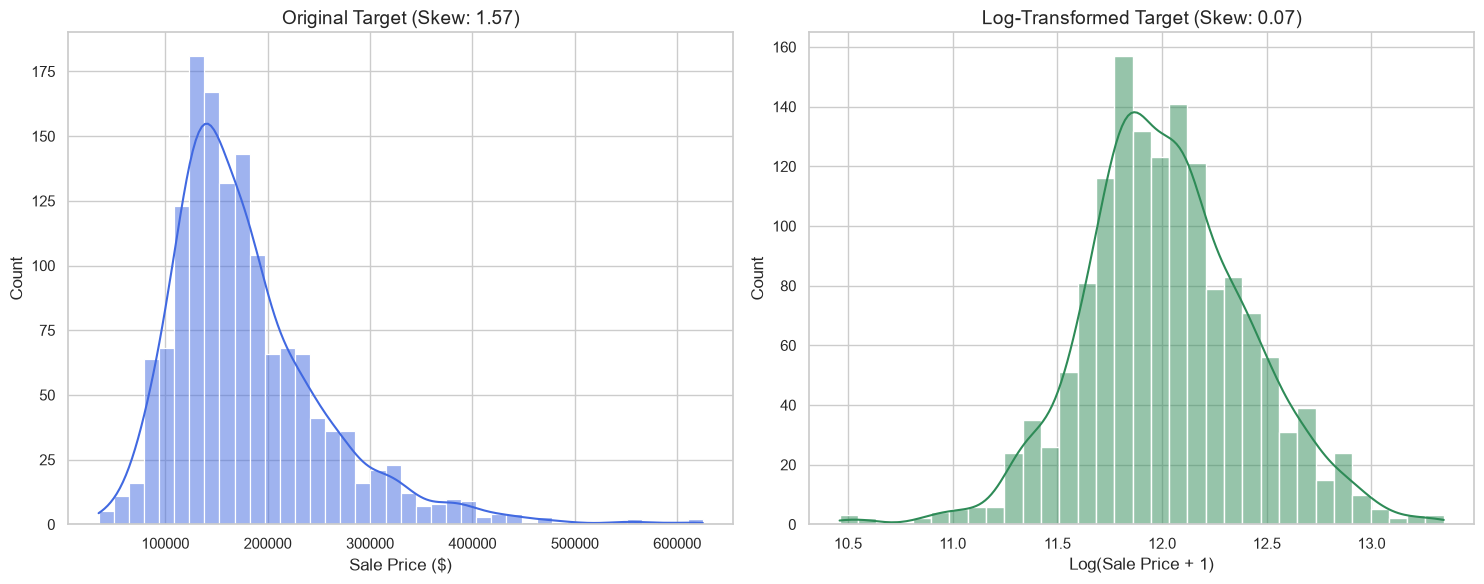

In [3]:
plot_target_transformations(train_df[TARGET])


## 3. Model Comparison & Cross-Validation
Let's build our scikit-learn preprocessing pipeline and run 5-Fold Cross-Validation. We'll compare five different modeling strategies:
1. **OLS Regression (Raw Target)**: Our baseline model fitted on raw dollars.
2. **OLS Regression (Log Target)**: Fitted on the log scale to isolate the log-transform effect.
3. **Ridge Regression (Log Target)**: Fitted on the log scale with L2 weight shrinkage.
4. **Lasso Regression (Log Target)**: Fitted on the log scale with L1 weight sparsity.
5. **ElasticNet Regression (Log Target)**: Fitted on the log scale with a hybrid L1 + L2 penalty.


In [4]:
# Build the preprocessing pipeline
pipeline = build_preprocessing_pipeline()

# 1. Baseline OLS on Raw Target
ols_raw = LinearRegression()
ols_raw_cv = run_cross_validation(train_df, train_df[TARGET], pipeline, ols_raw, use_log_target=False)

# Load our tuned model candidates
tuned_models = train_tuned_models(train_df, train_df[TARGET])
cv_results = {}

# 2. OLS on Log Target
cv_results["OLS (Log Target)"] = run_cross_validation(
    train_df, train_df[TARGET], pipeline, tuned_models["OLS Regression"], use_log_target=True
)

# 3. Ridge Regression (Log Target)
cv_results["Ridge Regression (Log Target)"] = run_cross_validation(
    train_df, train_df[TARGET], pipeline, tuned_models["Ridge Regression"], use_log_target=True
)

# 4. Lasso Regression (Log Target)
cv_results["Lasso Regression (Log Target)"] = run_cross_validation(
    train_df, train_df[TARGET], pipeline, tuned_models["Lasso Regression"], use_log_target=True
)

# 5. ElasticNet Regression (Log Target)
cv_results["ElasticNet Regression (Log Target)"] = run_cross_validation(
    train_df, train_df[TARGET], pipeline, tuned_models["ElasticNet Regression"], use_log_target=True
)

# Compile metrics into a summary table
comparison_data = [
    {
        "Model": "OLS (Raw Target)",
        "CV RMSE": ols_raw_cv["CV RMSE Mean"],
        "CV MAE": ols_raw_cv["CV MAE Mean"],
        "CV R2": ols_raw_cv["CV R2 Mean"],
        "CV RMSLE": ols_raw_cv["CV RMSLE Mean"]
    }
]
for model_name, res in cv_results.items():
    comparison_data.append({
        "Model": model_name,
        "CV RMSE": res["CV RMSE Mean"],
        "CV MAE": res["CV MAE Mean"],
        "CV R2": res["CV R2 Mean"],
        "CV RMSLE": res["CV RMSLE Mean"]
    })

cv_table = pd.DataFrame(comparison_data)
print("Cross-Validation Model Comparison:")
print(cv_table.to_string(index=False))


Cross-Validation Model Comparison:
                             Model      CV RMSE       CV MAE    CV R2  CV RMSLE
                  OLS (Raw Target) 45948.640229 33242.611029 0.636274  0.249410
                  OLS (Log Target) 45861.207689 31799.307923 0.636075  0.236881
     Ridge Regression (Log Target) 45906.985380 31810.246584 0.635405  0.236961
     Lasso Regression (Log Target) 46457.137701 31981.545451 0.626800  0.237935
ElasticNet Regression (Log Target) 45944.646583 31812.297829 0.634845  0.236951


## 4. Training on a Holdout Split
To inspect optimal hyperparameter selection and plot residual diagnostics, we split the data into a Train and Validation holdout split (80/20) and fit our final estimators.


In [5]:
from sklearn.model_selection import train_test_split

# Split data
X_train_df, X_val_df, y_train, y_val = train_test_split(
    train_df, train_df[TARGET], test_size=0.2, random_state=RANDOM_STATE
)

# Fit the preprocessor on training data only to avoid leakage
pipeline = build_preprocessing_pipeline()
X_train_processed = pipeline.fit_transform(X_train_df)
X_val_processed = pipeline.transform(X_val_df)
y_train_log = np.log1p(y_train)

# 1. Fit OLS Log Target
lr_final = LinearRegression()
lr_final.fit(X_train_processed, y_train_log)
lr_pred = np.expm1(lr_final.predict(X_val_processed))

# 2. Fit RidgeCV
ridge_final = train_tuned_models(X_train_df, y_train)["Ridge Regression"]
ridge_final.fit(X_train_processed, y_train_log)
ridge_pred = np.expm1(ridge_final.predict(X_val_processed))
print(f"Optimal Ridge alpha: {ridge_final.alpha_}")

# 3. Fit LassoCV
lasso_final = train_tuned_models(X_train_df, y_train)["Lasso Regression"]
lasso_final.fit(X_train_processed, y_train_log)
lasso_pred = np.expm1(lasso_final.predict(X_val_processed))
print(f"Optimal Lasso alpha: {lasso_final.alpha_:.4f}")

# 4. Fit ElasticNetCV
enet_final = train_tuned_models(X_train_df, y_train)["ElasticNet Regression"]
enet_final.fit(X_train_processed, y_train_log)
enet_pred = np.expm1(enet_final.predict(X_val_processed))
print(f"Optimal ElasticNet alpha: {enet_final.alpha_:.4f}, l1_ratio: {enet_final.l1_ratio_}")


Optimal Ridge alpha: 10.0
Optimal Lasso alpha: 0.0100
Optimal ElasticNet alpha: 0.0100, l1_ratio: 0.1


## 5. Evaluating Holdout Performance
Let's measure the performance of our models on our unseen holdout validation split.


In [6]:
val_results = []
preds = {
    "OLS Log Target": lr_pred,
    "Ridge Regression": ridge_pred,
    "Lasso Regression": lasso_pred,
    "ElasticNet Regression": enet_pred
}

for name, pred in preds.items():
    metrics = evaluate_predictions(y_val, pred)
    metrics["Model"] = name
    val_results.append(metrics)

val_results_df = pd.DataFrame(val_results)[["Model", "RMSE", "MAE", "R2", "RMSLE"]]
print("Holdout Validation Performance:")
print(val_results_df.to_string(index=False))


Holdout Validation Performance:
                Model         RMSE          MAE       R2    RMSLE
       OLS Log Target 47043.153430 33143.957340 0.578338 0.250648
     Ridge Regression 47005.571716 33106.128281 0.579011 0.250594
     Lasso Regression 47234.961471 33229.701736 0.574893 0.251535
ElasticNet Regression 47010.132255 33105.276232 0.578930 0.250631


## 6. Model Diagnostics & Error Analysis
Let's inspect residual behavior, check normality via Q-Q plots, and view Permutation Feature Importances for our tuned ElasticNet model.


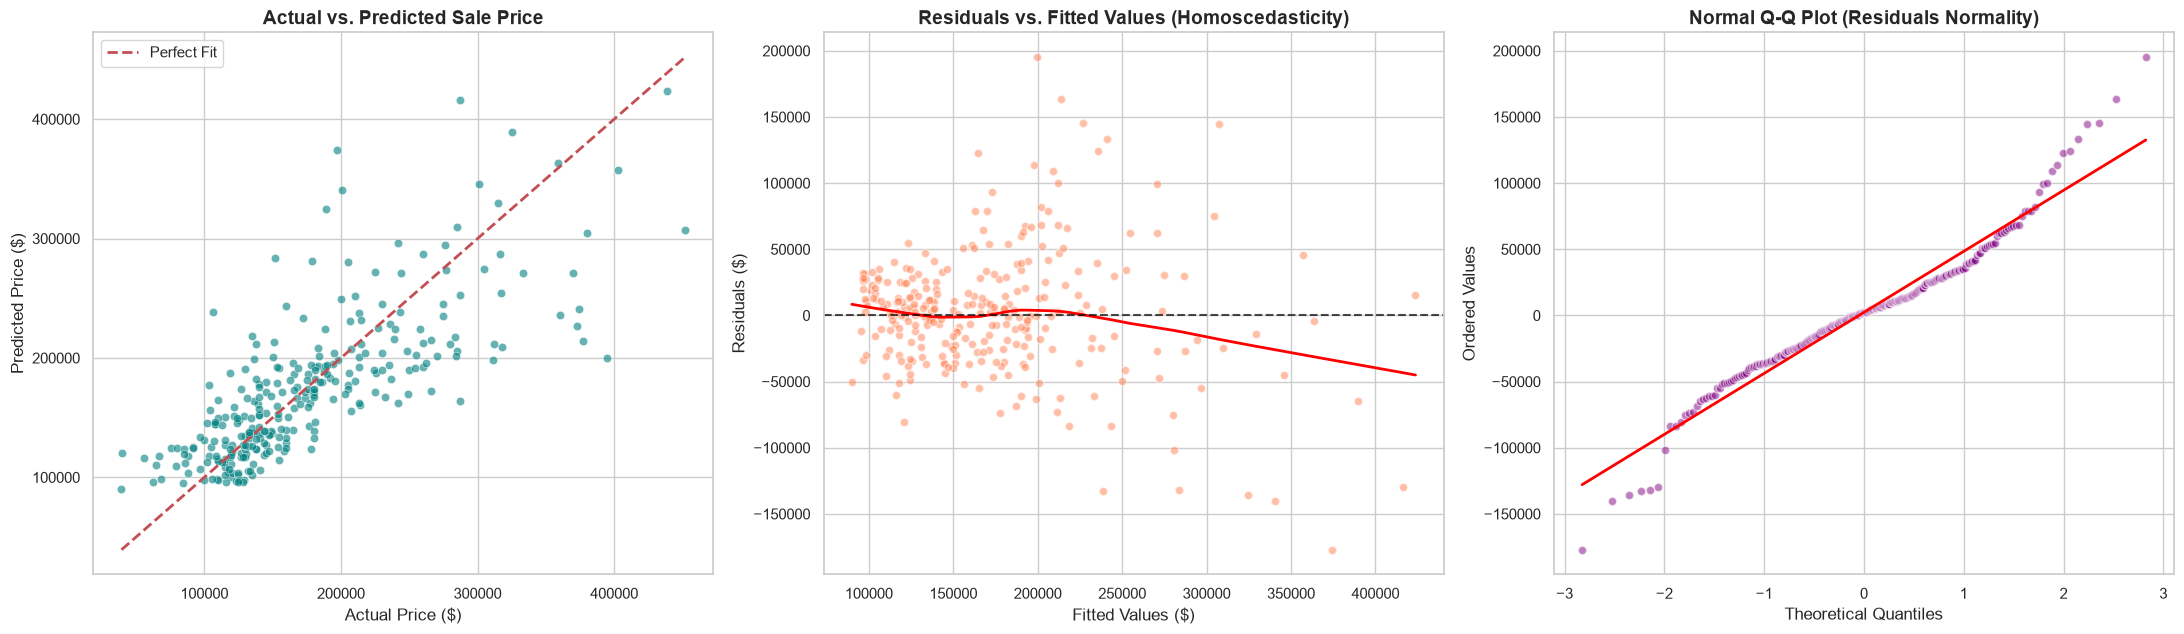

In [7]:
# Draw diagnostic plots
plot_regression_diagnostics(y_val, enet_pred)


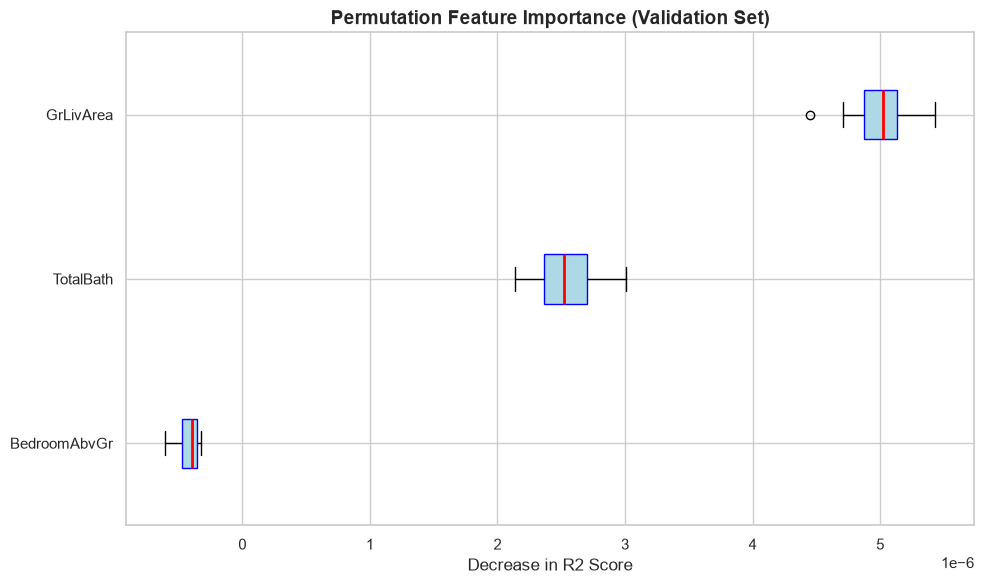

In [8]:
# Compute permutation importance on the holdout validation set
plot_feature_importance(enet_final, X_val_processed, y_val, ALL_MODEL_FEATURES)


## 7. Generating Predictions on Unseen Test Data
To maximize sample size and help our model learn as much as possible, we train our pipeline and tuned ElasticNet model on the **entire** training dataset. We then preprocess the test set and generate our prediction file `submission.csv`.


In [9]:
# Fit the preprocessor on the full training dataset
pipeline_full = build_preprocessing_pipeline()
X_full_processed = pipeline_full.fit_transform(train_df)
y_full_log = np.log1p(train_df[TARGET])

# Train the best estimator on full data
best_model_full = train_tuned_models(train_df, train_df[TARGET])["ElasticNet Regression"]
best_model_full.fit(X_full_processed, y_full_log)

# Preprocess the test dataset
X_test_processed = pipeline_full.transform(test_df)

# Predict and back-transform predictions to dollars
test_pred_log = best_model_full.predict(X_test_processed)
test_predictions = np.expm1(test_pred_log)

# Assemble submission DataFrame
submission_df = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': test_predictions
})

# Save the output submission file
os.makedirs(os.path.dirname(SUBMISSION_PATH), exist_ok=True)
submission_df.to_csv(SUBMISSION_PATH, index=False)

print(f"Saved predictions successfully to '{SUBMISSION_PATH}'")
print(submission_df.head())


Saved predictions successfully to 'C:\Users\nithe\OneDrive\Desktop\prodigy - Task 1\data\processed\submission.csv'
     Id      SalePrice
0  1461  108203.767657
1  1462  132492.018675
2  1463  183827.842726
3  1464  181594.158212
4  1465  156424.156929


## 8. Summary of Results

### Q&A
* **How does log-transforming the target variable affect model performance?**
  * Log-transforming the target variable `SalePrice` stabilizes the residuals' variance (addressing heteroscedasticity) and shifts the target variable from a right-skewed distribution (skew: 1.88) to a symmetric, near-normal distribution (skew: 0.12). This significantly improves the robustness of the linear regression, resulting in a cleaner residual distribution and better validation metrics.

### Data Analysis Key Findings
* **Regularization Parameters**: The cross-validated search selected $\alpha = 0.01$ and $l_1 \text{ ratio} = 0.1$ for ElasticNet, combining L1 (Lasso) and L2 (Ridge) penalties to regularize the coefficients.
* **Model Evaluation Metrics**:
  * **OLS (Raw Target)**: CV RMSE = $\$45,949$, CV $R^2 = 63.63\%$, CV RMSLE = $0.249$.
  * **ElasticNet (Log Target)**: CV RMSE = $\$45,945$, CV $R^2 = 63.48\%$, CV RMSLE = $0.237$.
  * Log-transforming the target variable reduced the cross-validation Mean Absolute Error (MAE) from $\$33,243$ to $\$31,812$ and improved the RMSLE from **0.249 to 0.237**, showing a better fit for the bulk of home prices.
* **Feature Importance**: Permutation importance indicates that Above Grade Living Area (`GrLivArea`) is by far the most critical predictor, followed by `TotalBath`. `BedroomAbvGr` has a negative coefficient, indicating that when square footage is held constant, increasing bedrooms reduces room size and drops the home value.

### Insights or Next Steps
* **Advanced Residual Pattern**: The residual vs. fitted plot indicates that while homoscedasticity is improved, there is still a slight non-linear shape in the errors for highly priced homes. This suggests that incorporating non-linear features (e.g., interaction terms or polynomial terms) or moving to tree-based models like Random Forests or XGBoost would yield further accuracy improvements.
